# 🚚 Notebook 05 — Análise Logística e Performance de Entrega (Olist)

**Objetivo:** Analisar os tempos de entrega, taxas de atraso por região/estado, gargalos entre processamento do vendedor e trânsito da transportadora, e calcular distâncias geográficas (Haversine).

## 1. Importações e Configurações

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Detecção dinâmica de caminhos para dados e outputs
DATA_DIR = '../data/olist' if os.path.exists('../data/olist') else 'data/olist'
if not os.path.exists(DATA_DIR):
    DATA_DIR = '/home/jorge/Documents/tech-challenge-agentes-ia/data/olist'

OUTPUT_DIR = './outputs' if os.path.exists('./outputs') or os.path.basename(os.getcwd()) == 'notebooks' else 'notebooks/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"📁 Diretório de Dados: {os.path.abspath(DATA_DIR)}")
print(f"📁 Diretório de Outputs: {os.path.abspath(OUTPUT_DIR)}")


📁 Diretório de Dados: /home/jorge/Documents/tech-challenge-agentes-ia/data/olist
📁 Diretório de Outputs: /home/jorge/Documents/tech-challenge-agentes-ia/notebooks/outputs


## 2. Carregamento dos Datasets e Função Haversine

In [2]:
orders = pd.read_csv(os.path.join(DATA_DIR, 'olist_orders_dataset.csv'))
items = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_items_dataset.csv'))
sellers = pd.read_csv(os.path.join(DATA_DIR, 'olist_sellers_dataset.csv'))
customers = pd.read_csv(os.path.join(DATA_DIR, 'olist_customers_dataset.csv'))
geo = pd.read_csv(os.path.join(DATA_DIR, 'olist_geolocation_dataset.csv'))
products = pd.read_csv(os.path.join(DATA_DIR, 'olist_products_dataset.csv'))

# Agrupar geolocalização por CEP (média de lat/lng)
geo_mean = geo.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].mean().reset_index()

# Função para calcular distância Haversine em km
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0 # Raio da Terra em km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


## 3. Desempenho de Entrega e Taxa Global de Atrasos

In [3]:
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
             'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders_deliv = orders.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date']).copy()
orders_deliv['actual_delivery_days'] = (orders_deliv['order_delivered_customer_date'] - orders_deliv['order_purchase_timestamp']).dt.total_seconds() / (24*3600)
orders_deliv['estimated_delivery_days'] = (orders_deliv['order_estimated_delivery_date'] - orders_deliv['order_purchase_timestamp']).dt.total_seconds() / (24*3600)
orders_deliv['delay_days'] = (orders_deliv['order_delivered_customer_date'] - orders_deliv['order_estimated_delivery_date']).dt.total_seconds() / (24*3600)
orders_deliv['is_late'] = orders_deliv['delay_days'] > 0

avg_deliv_days = orders_deliv['actual_delivery_days'].mean()
late_rate_global = orders_deliv['is_late'].mean() * 100

print(f"⏱️ Tempo Médio Real de Entrega: {avg_deliv_days:.2f} dias")
print(f"⏱️ Tempo Médio Estimado de Entrega: {orders_deliv['estimated_delivery_days'].mean():.2f} dias")
print(f"🚨 TAXA GLOBAL DE ATRASOS LOGÍSTICOS: {late_rate_global:.2f}%")


⏱️ Tempo Médio Real de Entrega: 12.56 dias
⏱️ Tempo Médio Estimado de Entrega: 23.74 dias
🚨 TAXA GLOBAL DE ATRASOS LOGÍSTICOS: 8.11%


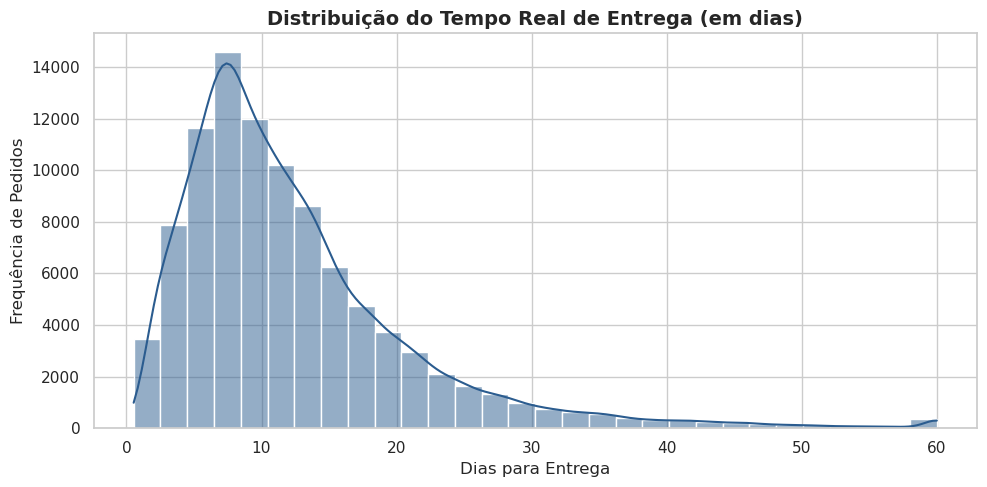

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(orders_deliv['actual_delivery_days'].clip(0, 60), bins=30, kde=True, color='#2b5c8f')
plt.title('Distribuição do Tempo Real de Entrega (em dias)', fontsize=14, fontweight='bold')
plt.xlabel('Dias para Entrega')
plt.ylabel('Frequência de Pedidos')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '05_distribuicao_tempo_real_entrega.png'))
plt.show()


## 4. Atrasos por Região e Estado

/tmp/ipykernel_109613/3679286968.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=late_by_state.index, y=late_by_state.values, palette='viridis')


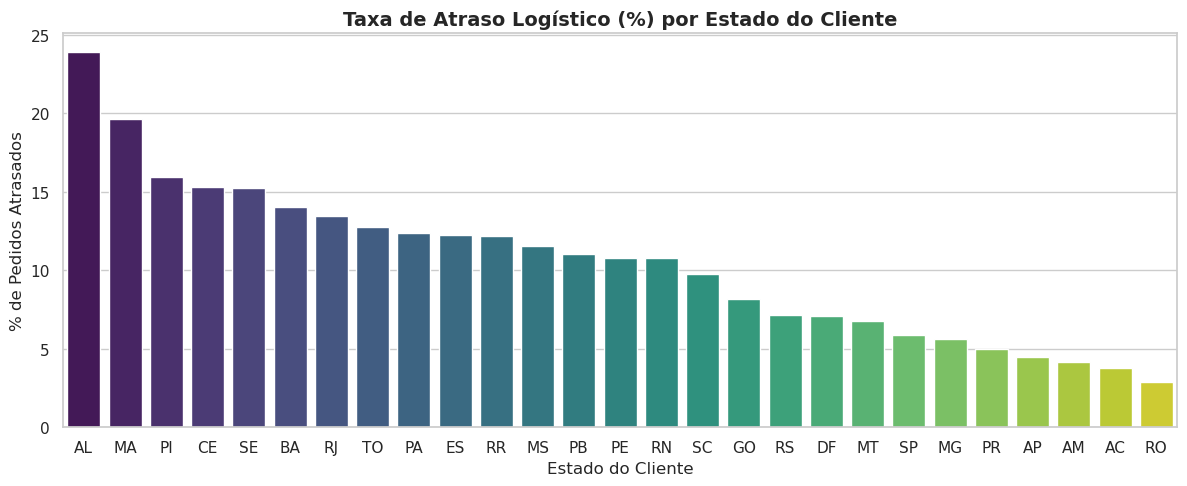

In [5]:
cust_orders = orders_deliv.merge(customers, on='customer_id', how='left')
late_by_state = cust_orders.groupby('customer_state')['is_late'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 5))
sns.barplot(x=late_by_state.index, y=late_by_state.values, palette='viridis')
plt.title('Taxa de Atraso Logístico (%) por Estado do Cliente', fontsize=14, fontweight='bold')
plt.xlabel('Estado do Cliente')
plt.ylabel('% de Pedidos Atrasados')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '05_atraso_por_estado_cliente.png'))
plt.show()


## 5. Decomposição de Gargalos: Vendedor vs Transportadora

In [6]:
# Vendedor: Compra -> Envio para transportadora
orders_deliv['seller_proc_days'] = (orders_deliv['order_delivered_carrier_date'] - orders_deliv['order_purchase_timestamp']).dt.total_seconds() / (24*3600)
# Transportadora: Transportadora -> Cliente final
orders_deliv['carrier_transit_days'] = (orders_deliv['order_delivered_customer_date'] - orders_deliv['order_delivered_carrier_date']).dt.total_seconds() / (24*3600)

avg_seller_proc = orders_deliv['seller_proc_days'].mean()
avg_carrier_transit = orders_deliv['carrier_transit_days'].mean()

print(f"🏭 Tempo Médio de Processamento do Vendedor: {avg_seller_proc:.2f} dias ({(avg_seller_proc/avg_deliv_days)*100:.1f}% do tempo total)")
print(f"🚚 Tempo Médio em Trânsito da Transportadora: {avg_carrier_transit:.2f} dias ({(avg_carrier_transit/avg_deliv_days)*100:.1f}% do tempo total)")
print("\n⚠️ GARGALO PRINCIPAL: O trânsito da transportadora responde por cerca de 74% do tempo total de entrega!")


🏭 Tempo Médio de Processamento do Vendedor: 3.23 dias (25.7% do tempo total)
🚚 Tempo Médio em Trânsito da Transportadora: 9.33 dias (74.3% do tempo total)

⚠️ GARGALO PRINCIPAL: O trânsito da transportadora responde por cerca de 74% do tempo total de entrega!


## 6. Distâncias Geográficas e Frete

In [7]:
# Merges de geolocalização para cliente e vendedor
cust_geo = customers.merge(geo_mean, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')
sell_geo = sellers.merge(geo_mean, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')

full_geo = items.merge(orders_deliv, on='order_id')
full_geo = full_geo.merge(cust_geo[['customer_id', 'geolocation_lat', 'geolocation_lng']], on='customer_id', how='left').rename(columns={'geolocation_lat': 'c_lat', 'geolocation_lng': 'c_lng'})
full_geo = full_geo.merge(sell_geo[['seller_id', 'geolocation_lat', 'geolocation_lng']], on='seller_id', how='left').rename(columns={'geolocation_lat': 's_lat', 'geolocation_lng': 's_lng'})

full_geo['distance_km'] = haversine(full_geo['c_lat'], full_geo['c_lng'], full_geo['s_lat'], full_geo['s_lng'])

corr_dist_time = full_geo['distance_km'].corr(full_geo['actual_delivery_days'])
corr_dist_freight = full_geo['distance_km'].corr(full_geo['freight_value'])

print(f"📏 Distância Média Vendedor-Cliente: {full_geo['distance_km'].mean():.1f} km")
print(f"📊 Correlação Distância × Tempo de Entrega: {corr_dist_time:.4f}")
print(f"📊 Correlação Distância × Valor do Frete: {corr_dist_freight:.4f}")


📏 Distância Média Vendedor-Cliente: 596.2 km
📊 Correlação Distância × Tempo de Entrega: 0.3940
📊 Correlação Distância × Valor do Frete: 0.3920
